In [2]:
import numpy as np
from xgboost import XGBClassifier

In [3]:
# load processed data from npy files
X_train = np.load('data/X_train.npy')
y_train = np.load('data/y_train.npy')
X_test = np.load('data/X_test.npy')
y_test = np.load('data/y_test.npy')

In [4]:
# train XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)
print("Model training complete.")

c:\Users\JanderM\AppData\Local\anaconda3\envs\xai-project\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:45:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model training complete.


In [5]:
# test model
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
print("Test Predictions:", y_pred)
print("Test Prediction Probabilities:", y_pred_proba)
print("Model testing complete.")

Test Predictions: [0 0 0 ... 1 0 0]
Test Prediction Probabilities: [0.36869982 0.10369452 0.2842923  ... 0.64423144 0.45009184 0.2560604 ]
Model testing complete.


AUC: 0.6579647946967593, F1 Score: 0.3825407055218454


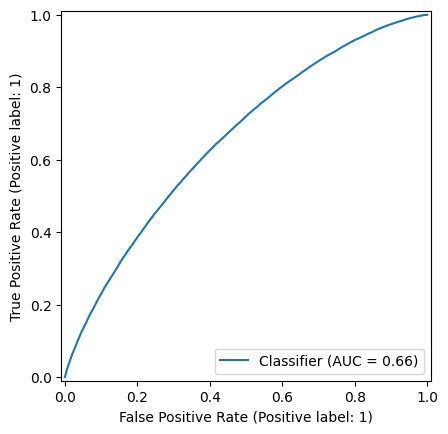

In [6]:
# evaluate model
from sklearn.metrics import roc_auc_score, f1_score, RocCurveDisplay

auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
print(f"AUC: {auc}, F1 Score: {f1}")

# plot RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_pred_proba);


AUC: 0.6580, PR AUC: 0.3077, F1@0.5: 0.3825
Best F1: 0.3830 at threshold: 0.497


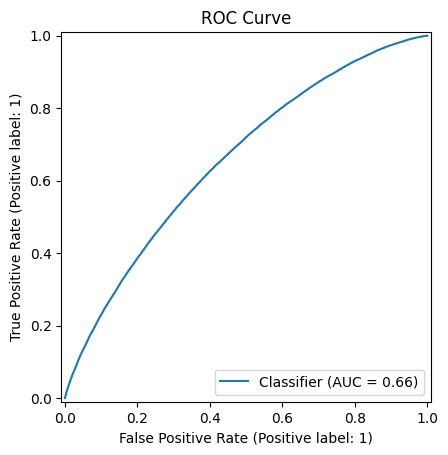

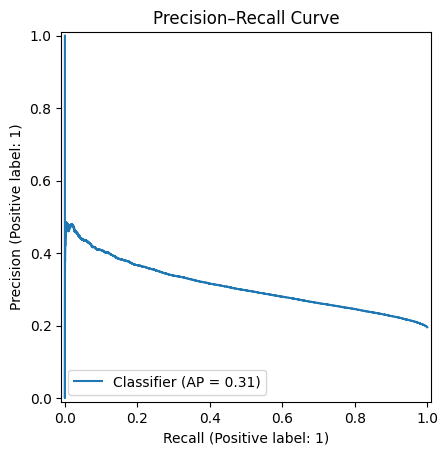

✅ Results saved to results\eval_20251014_154532.json
0.3829986436360763 0.49673914909362793


In [7]:
from utils import evaluate_predictions

# after generating y_pred_proba from your model
results = evaluate_predictions(y_test, y_pred_proba)

print(results["best_f1"], results["best_threshold"])


In [8]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform
from xgboost import XGBClassifier

neg, pos = (y_train==0).sum(), (y_train==1).sum()
spw = neg / max(pos, 1)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",      # if GPU: "gpu_hist"
    n_jobs=-1,
    scale_pos_weight=spw,
    random_state=42
)

param_dist = {
    "n_estimators": randint(300, 1200),
    "learning_rate": loguniform(1e-3, 2e-1),
    "max_depth": randint(3, 10),
    "min_child_weight": loguniform(1e-1, 1e+2),
    "subsample": uniform(0.6, 0.4),         # [0.6, 1.0]
    "colsample_bytree": uniform(0.6, 0.4),  # [0.6, 1.0]
    "gamma": loguniform(1e-9, 1e-1),
    "reg_lambda": loguniform(1e-3, 1e+2),
    "reg_alpha": loguniform(1e-6, 1e+1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,                 # 50–150 is a good band
    scoring="average_precision",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    refit=True
)

search.fit(X_train, y_train)
best_model = search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [9]:
# Get predictions from best tuned XGBoost model

# Predicted probabilities (for positive class = 1)
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]

# Predicted labels at default threshold = 0.5
y_pred_tuned = (y_pred_proba_tuned >= 0.5).astype(int)

print(f"Shapes -> y_pred: {y_pred_tuned.shape}, y_pred_proba: {y_pred_proba_tuned.shape}")
print(f"Example probabilities: {y_pred_proba_tuned[:5]}")
print(f"Example predictions: {y_pred_tuned[:5]}")


Shapes -> y_pred: (253899,), y_pred_proba: (253899,)
Example probabilities: [0.34842992 0.10605484 0.32228562 0.6617422  0.45068553]
Example predictions: [0 0 0 1 0]


AUC: 0.6610, PR AUC: 0.3117, F1@0.5: 0.3852
Best F1: 0.3854 at threshold: 0.497


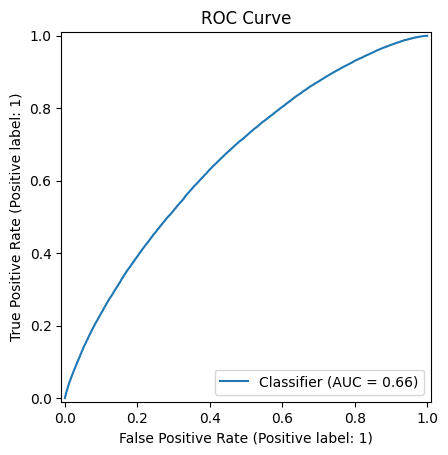

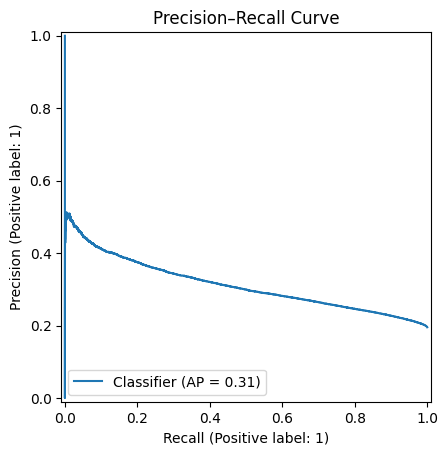

✅ Results saved to results\eval_20251014_161610.json
0.3854244246240187 0.4973624050617218


In [10]:
# after generating y_pred_proba from your model
results_tuned = evaluate_predictions(y_test, y_pred_proba_tuned)

print(results_tuned["best_f1"], results_tuned["best_threshold"])


In [14]:

import shap
from matplotlib import pyplot as plt
# ---------- feature names ----------
feature_names = [k for k, _ in sorted(idx.items(), key=lambda kv: kv[1])]
print("Feature names (by column order):", feature_names)

# ---------- sampling for speed ----------
n = X_test.shape[0]
sample_size = min(10000, n)
rng = np.random.RandomState(42)
sample_idx = rng.choice(n, size=sample_size, replace=False)
X_sample = X_test[sample_idx]

# background for interventional (use ~1k rows)
bg_size = min(1000, X_train.shape[0])
bg_idx = rng.choice(X_train.shape[0], size=bg_size, replace=False)
X_bg = X_train[bg_idx]

# ---------- build explainer (probability space, interventional) ----------
explainer = shap.TreeExplainer(
    best_model,
    data=X_bg,                              # <-- provide background
    feature_perturbation="interventional",  # now valid
    model_output="probability"              # probabilities for classifier
)

# ---------- compute SHAP ----------
# Newer SHAP API: explainer(X) -> Explanation
try:
    exp = explainer(X_sample)
    shap_values = exp.values  # (n_samples, n_features)
    base_value = np.array(exp.base_values).mean()  # scalar-ish
except TypeError:
    # Older API fallback
    shap_values = explainer.shap_values(X_sample)  # (n_samples, n_features) for binary
    base_value = explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[1]

print("Base value (expected model output):", float(base_value))

# ---------- global importance ----------
mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(-mean_abs)
print("Global SHAP importance (top 10):")
for i in order[:10]:
    print(f"{feature_names[i]:>15s}  {mean_abs[i]:.6f}")

# ---------- plots ----------
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.tight_layout(); plt.savefig("shap_summary_beeswarm.png", dpi=150); plt.close()

plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout(); plt.savefig("shap_summary_bar.png", dpi=150); plt.close()

print("Saved: shap_summary_beeswarm.png, shap_summary_bar.png")

# ---------- dependence plots for top 3 ----------
top_feats = [feature_names[i] for i in order[:3]]
for f in top_feats:
    plt.figure()
    shap.dependence_plot(f, shap_values, X_sample, feature_names=feature_names, show=False, interaction_index=None)
    plt.tight_layout()
    out = f"shap_dependence_{f}.png".replace("/", "_")
    plt.savefig(out, dpi=150); plt.close()
    print(f"Saved: {out}")

# ---------- per-row explanation ----------
row = 0
sv_row = shap_values[row]
contribs = sorted(zip(feature_names, sv_row), key=lambda x: abs(x[1]), reverse=True)
print("\nRow-level contributions (top 10):")
for name, val in contribs[:10]:
    print(f"{name:>15s}  {val:+.5f}")


Feature names (by column order): ['revenue', 'dti_n', 'loan_amnt', 'fico_n', 'emp_length', 'business', 'home_equity']


100%|===================| 9960/10000 [01:37<00:00]        

Base value (expected model output): 0.5143290352912576
Global SHAP importance (top 10):
      loan_amnt  0.078698
         fico_n  0.073310
        revenue  0.045522
          dti_n  0.042685
    home_equity  0.035053
     emp_length  0.006244
       business  0.003802
Saved: shap_summary_beeswarm.png, shap_summary_bar.png
Saved: shap_dependence_loan_amnt.png
Saved: shap_dependence_fico_n.png
Saved: shap_dependence_revenue.png

Row-level contributions (top 10):
      loan_amnt  +0.07975
          dti_n  +0.06465
        revenue  -0.04100
    home_equity  -0.03736
         fico_n  -0.01392
     emp_length  -0.00564
       business  -0.00183


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>